# Fall Detection — Configuration 03: Real ADLs + All Generated ADLs (TimeGAN)

Third notebook in the series, following the same pipeline and 1D CNN architecture as
Configuration 01 and Configuration 02.

**What's different in Configuration 03 (per the inspection output):**
* **6084 samples** total: 1014 REAL + 5070 GENERATED (TimeGAN), vs 1509 in Configuration 02.
* GENERATED samples now cover **both classes** (4575 GENERATED NON_FALL + 495 GENERATED
  FALL), not just FALL as in Configuration 02.
* Overall class balance is back to **90.24% NON_FALL / 9.76% FALL** — identical to
  Configuration 01 — because NON_FALL was upsampled by generation at the same ratio as
  FALL (multiplier = 5.0 for the generated rows in both classes).

**On `source_sample_id` — checked and found unreliable for provenance.** An earlier
version of this notebook assumed `source_sample_id` traced each GENERATED row back to its
originating REAL sample (and therefore to a subject), and used that to assign GENERATED
rows to TRAIN/VAL/TEST by inheritance. Running it against the real data showed this is
wrong: `source_sample_id` values for GENERATED rows run up into the 5000s — past the REAL
data's `sample_id` range (0–1013, 1014 rows) — which matches the size of the GENERATED
pool itself (5070 rows). In other words, `source_sample_id` is an internal counter over
the generated samples, not a back-reference to a REAL sample or subject. Section 2 checks
this explicitly (without crashing the notebook), and Section 3 no longer relies on it.

**Leakage-prevention rule used in this notebook (same as Configuration 02, since real
provenance can't be recovered from this metadata):**
1. Compute the REAL subject-wise TRAIN/VAL/TEST partition exactly as in Configurations 01
   and 02 (search over REAL-subject partitions).
2. REAL samples are assigned to TRAIN/VAL/TEST by their subject's assignment.
3. **All GENERATED rows (both classes) are assigned to TRAIN only.** VALIDATION and TEST
   remain 100% REAL, from held-out subjects — exactly as in Configurations 01 and 02 — so
   all three configurations' test metrics stay directly comparable. As with Configuration
   02, we cannot rule out that some GENERATED windows were derived from REAL data
   belonging to a VAL/TEST subject; this is a limitation of the metadata, not of the split
   logic, and is called out again in Section 3.


## 0. Configuration

In [16]:
import os
import json
import random
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Paths (edit these to match your environment)
# ---------------------------------------------------------------------------
CONFIG_NAME   = "03-Real_ADLs+All_Generated_ADLs"
DATA_ROOT     = os.path.join("Classification_Datasets", CONFIG_NAME)
NPY_PATH      = os.path.join(DATA_ROOT, "features.npy")      # <-- adjust filename if different
METADATA_PATH = os.path.join(DATA_ROOT, "metadata.csv")      # <-- adjust filename if different

OUTPUT_DIR = os.path.join("Results", CONFIG_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------------
# Split configuration (subject-wise, computed on REAL subjects only)
# ---------------------------------------------------------------------------
N_TEST_SUBJECTS = 2   # REAL subjects held out for the final REAL test set
N_VAL_SUBJECTS  = 2   # REAL subjects held out for validation
# Remaining REAL subjects (10 - 2 - 2 = 6) form the TRAIN subject pool; GENERATED rows
# whose source subject is in this pool are added to TRAIN (see Section 3).

# ---------------------------------------------------------------------------
# Training configuration (kept identical to Configurations 01/02 for comparability)
# ---------------------------------------------------------------------------
BATCH_SIZE     = 32
MAX_EPOCHS     = 200
LEARNING_RATE  = 1e-3
EARLY_STOP_PATIENCE = 20
LR_PATIENCE    = 8
LR_FACTOR      = 0.5
DROPOUT_RATE   = 0.3

print("Configuration loaded.")
print(f"  Config name : {CONFIG_NAME}")
print(f"  NPY path    : {NPY_PATH}")
print(f"  Metadata    : {METADATA_PATH}")
print(f"  Output dir  : {OUTPUT_DIR}")
print(f"  Seed        : {SEED}")


Configuration loaded.
  Config name : 03-Real_ADLs+All_Generated_ADLs
  NPY path    : Classification_Datasets\03-Real_ADLs+All_Generated_ADLs\features.npy
  Metadata    : Classification_Datasets\03-Real_ADLs+All_Generated_ADLs\metadata.csv
  Output dir  : Results\03-Real_ADLs+All_Generated_ADLs
  Seed        : 42


## 1. Load Dataset

In [17]:
import os
import numpy as np
import pandas as pd

BASE_DIR = r"C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model"
DATASET_DIR = os.path.join(BASE_DIR, "Classification_Datasets", "03-Real_ADLs+All_Generated_ADLs")

NPY_PATH = os.path.join(DATASET_DIR, "X_imu_radar.npy")
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.csv")

assert os.path.exists(NPY_PATH), f"NPY file not found: {NPY_PATH}"
assert os.path.exists(METADATA_PATH), f"Metadata file not found: {METADATA_PATH}"

X_all = np.load(NPY_PATH)
metadata = pd.read_csv(METADATA_PATH)

print("Dataset path   :", NPY_PATH)
print("Metadata path  :", METADATA_PATH)
print("Array shape    :", X_all.shape)
print("Array dtype    :", X_all.dtype)
print("Metadata rows  :", len(metadata))
print("Num samples    :", X_all.shape[0])
print("Time frames    :", X_all.shape[1])
print("Num features   :", X_all.shape[2])

if len(X_all) != len(metadata):
    raise ValueError(
        f"Alignment error: len(X)={len(X_all)} != len(metadata)={len(metadata)}. "
        "Stopping — do not proceed with misaligned data."
    )
print("\n[OK] Array and metadata are aligned:", len(X_all), "==", len(metadata))


Dataset path   : C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model\Classification_Datasets\03-Real_ADLs+All_Generated_ADLs\X_imu_radar.npy
Metadata path  : C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model\Classification_Datasets\03-Real_ADLs+All_Generated_ADLs\metadata.csv
Array shape    : (6084, 32, 1137)
Array dtype    : float32
Metadata rows  : 6084
Num samples    : 6084
Time frames    : 32
Num features   : 1137

[OK] Array and metadata are aligned: 6084 == 6084


## 2. Dataset & Metadata Sanity Checks

Same 19-column schema as Configuration 02, but now GENERATED rows exist for **both**
classes, and `source_sample_id` is populated for every GENERATED row — we validate that
traceability directly, since Section 3's leakage-prevention split depends on it.

In [18]:
print("=" * 70)
print("SANITY CHECKS — Configuration 03: Real ADLs + All Generated ADLs")
print("=" * 70)

expected_cols = [
    "sample_id", "label", "class_id", "activity_type", "source",
    "generation_type", "generation_class", "source_sample_id", "subject_id",
    "fall_id", "fall_number", "segment_id", "center_time", "window_start",
    "window_end", "original_frame_count", "target_frames", "feature_count",
    "multiplier",
]
missing_cols = [c for c in expected_cols if c not in metadata.columns]
if missing_cols:
    raise ValueError(f"Missing expected metadata columns: {missing_cols}")
print("[OK] All expected metadata columns are present.")

# --- Unique sample_id -------------------------------------------------------
n_unique_ids = metadata["sample_id"].nunique()
assert n_unique_ids == len(metadata), (
    f"sample_id is not unique: {n_unique_ids} unique vs {len(metadata)} rows"
)
print(f"[OK] sample_id is unique ({n_unique_ids} values).")

# --- Valid labels / source ---------------------------------------------------
valid_labels = {"FALL", "NON_FALL"}
found_labels = set(metadata["label"].unique())
assert found_labels.issubset(valid_labels), f"Unexpected label values: {found_labels}"

valid_sources = {"REAL", "GENERATED"}
found_sources = set(metadata["source"].unique())
assert found_sources.issubset(valid_sources), f"Unexpected source values: {found_sources}"
print(f"[OK] Labels valid: {found_labels}   Sources valid: {found_sources}")

# --- label / class_id / generation_class consistency ------------------------
label_to_class = {"NON_FALL": 0, "FALL": 1}
mismatches = metadata[metadata["class_id"] != metadata["label"].map(label_to_class)]
assert len(mismatches) == 0, f"{len(mismatches)} rows where class_id disagrees with label."
print("[OK] class_id is consistent with label for all rows.")

gen_rows = metadata[metadata["source"] == "GENERATED"]
real_rows = metadata[metadata["source"] == "REAL"]
gen_mismatch = gen_rows[gen_rows["label"] != gen_rows["generation_class"]]
assert len(gen_mismatch) == 0, f"{len(gen_mismatch)} GENERATED rows where label != generation_class."
print(f"[OK] label matches generation_class for all {len(gen_rows)} GENERATED rows.")

# --- Class distribution -------------------------------------------------------
label_counts = metadata["label"].value_counts()
label_pct = metadata["label"].value_counts(normalize=True) * 100
print("\nOverall class distribution:")
for lbl in label_counts.index:
    print(f"  {lbl:10s}: {label_counts[lbl]:5d} ({label_pct[lbl]:5.2f}%)")

source_counts = metadata["source"].value_counts()
print("\nREAL vs GENERATED:")
print(source_counts.to_string())

by_source = pd.crosstab(metadata["source"], metadata["label"])
print("\nLabel distribution by source:")
print(by_source)
print("\n[Note] Unlike Configuration 02, GENERATED rows here span BOTH classes "
      f"({(gen_rows['label'] == 'FALL').sum()} FALL, {(gen_rows['label'] == 'NON_FALL').sum()} NON_FALL).")

# --- subject_id only defined for REAL rows -----------------------------------
assert metadata.loc[metadata["source"] == "GENERATED", "subject_id"].isna().all(), (
    "Expected subject_id to be NaN for all GENERATED rows."
)
print("\n[OK] subject_id is NaN for all GENERATED rows, as expected.")

subject_counts = real_rows["subject_id"].value_counts().sort_index()
print("\nSubject distribution (REAL rows only):")
print(subject_counts.to_string())

per_subject = pd.crosstab(real_rows["subject_id"], real_rows["label"])
print("\nFALL / NON_FALL per REAL subject:")
print(per_subject)

# --- source_sample_id: check whether it is actually usable for provenance ---
# IMPORTANT: do not assume this column back-references a REAL sample_id. We check it
# here, diagnostically, rather than asserting on it -- if it doesn't resolve cleanly to
# REAL sample_ids, we treat it as NOT usable for provenance and say so explicitly,
# instead of crashing the notebook or silently trusting a broken assumption.
frac_missing_source_id = metadata["source_sample_id"].isna().mean()
n_generated = len(gen_rows)
n_gen_with_source = gen_rows["source_sample_id"].notna().sum()
print(f"\nsource_sample_id missing overall: {frac_missing_source_id*100:.2f}%")
print(f"GENERATED rows with a non-null source_sample_id: {n_gen_with_source} / {n_generated}")

real_sample_ids = set(real_rows["sample_id"].tolist())
gen_source_ids = gen_rows["source_sample_id"].dropna().astype(int)
n_resolved = int(gen_source_ids.isin(real_sample_ids).sum())
n_unresolved = len(gen_source_ids) - n_resolved
print(f"source_sample_id values that resolve to a REAL sample_id : {n_resolved} / {len(gen_source_ids)}")
print(f"source_sample_id values that do NOT resolve to a REAL row: {n_unresolved} / {len(gen_source_ids)}")
if len(gen_source_ids) > 0:
    print(f"source_sample_id range: [{gen_source_ids.min()}, {gen_source_ids.max()}]  "
          f"vs REAL sample_id range: [{min(real_sample_ids)}, {max(real_sample_ids)}]")

SOURCE_SAMPLE_ID_USABLE_FOR_PROVENANCE = (n_unresolved == 0) and (n_gen_with_source == n_generated)

if SOURCE_SAMPLE_ID_USABLE_FOR_PROVENANCE:
    print("\n[OK] source_sample_id resolves cleanly to REAL sample_ids for every GENERATED "
          "row -- it will be used in Section 3 to inherit each GENERATED row's subject/split.")
else:
    print("\n[CAVEAT] source_sample_id does NOT reliably reference a REAL sample_id in this "
          "export (it looks like an internal counter over the GENERATED pool itself -- its "
          "range typically runs well past the REAL sample_id range). This means we CANNOT "
          "verify which REAL subject each GENERATED sample was derived from. Section 3 "
          "therefore falls back to the same rule used in Configuration 02: ALL GENERATED "
          "rows go to TRAIN only, and we cannot fully rule out that some of them were "
          "derived from REAL data belonging to a VAL/TEST subject.")

# --- Missing values -----------------------------------------------------------
missing = metadata.isna().sum()
missing = missing[missing > 0]
print("\nMissing values per column:")
print(missing.to_string())
print("\nNote: this missingness is structural (subject/window/fall fields exist only for "
      "REAL rows; multiplier only for GENERATED rows) and source_sample_id is only "
      "expected to be missing for REAL rows.")

# --- NaN / Inf in the feature array ------------------------------------------
n_nan = np.isnan(X_all).sum()
n_inf = np.isinf(X_all).sum()
print(f"\nNaN values in X_all: {n_nan}")
print(f"Inf values in X_all: {n_inf}")
if n_nan > 0 or n_inf > 0:
    raise ValueError(
        f"Data quality issue: {n_nan} NaNs and {n_inf} Infs found in the feature array. "
        "Investigate before proceeding."
    )
print("[OK] No NaN or Inf values in the feature array.")

# --- Shape checks -------------------------------------------------------------
n_samples, n_frames, n_features = X_all.shape
assert (metadata["target_frames"] == n_frames).all(), "target_frames mismatch with array shape"
assert (metadata["feature_count"] == n_features).all(), "feature_count mismatch with array shape"
print(f"[OK] Shape consistent with metadata: samples={n_samples}, frames={n_frames}, features={n_features}")

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total samples     : {n_samples}  (REAL={len(real_rows)}, GENERATED={len(gen_rows)})")
print(f"Time frames       : {n_frames}")
print(f"Features          : {n_features}")
print(f"FALL              : {label_counts.get('FALL', 0)} ({label_pct.get('FALL', 0):.2f}%)")
print(f"NON_FALL          : {label_counts.get('NON_FALL', 0)} ({label_pct.get('NON_FALL', 0):.2f}%)")
print(f"REAL subjects     : {real_rows['subject_id'].nunique()}")


SANITY CHECKS — Configuration 03: Real ADLs + All Generated ADLs
[OK] All expected metadata columns are present.
[OK] sample_id is unique (6084 values).
[OK] Labels valid: {'FALL', 'NON_FALL'}   Sources valid: {'REAL', 'GENERATED'}
[OK] class_id is consistent with label for all rows.
[OK] label matches generation_class for all 5070 GENERATED rows.

Overall class distribution:
  NON_FALL  :  5490 (90.24%)
  FALL      :   594 ( 9.76%)

REAL vs GENERATED:
source
GENERATED    5070
REAL         1014

Label distribution by source:
label      FALL  NON_FALL
source                   
GENERATED   495      4575
REAL         99       915

[Note] Unlike Configuration 02, GENERATED rows here span BOTH classes (495 FALL, 4575 NON_FALL).

[OK] subject_id is NaN for all GENERATED rows, as expected.

Subject distribution (REAL rows only):
subject_id
1.0     172
2.0      96
3.0     115
4.0      93
5.0      96
6.0      91
7.0      86
8.0      83
9.0      71
10.0    111

FALL / NON_FALL per REAL subject:


## 3. Subject-Wise Split (REAL subjects) + Generated-to-Train Assignment

Step 1 is identical to Configurations 01/02: partition the 10 REAL subjects into
TRAIN/VAL/TEST with the same randomized search (rejecting partitions that leave any split
without FALL samples, scoring by closeness to the overall REAL FALL fraction).

Step 2 depends on whether Section 2 found `source_sample_id` usable for provenance:
* **If usable** (every GENERATED row resolves to a real `sample_id`): each GENERATED row
  inherits its source REAL row's subject/split. A GENERATED row whose source is a VAL/TEST
  subject is excluded entirely (not put in TRAIN, and not put in VAL/TEST, which must stay
  REAL-only).
* **If not usable** (the case for this export — see Section 2's caveat): we fall back to
  the Configuration 02 rule and put **all** GENERATED rows in TRAIN, since we have no
  reliable way to know which REAL subject (if any) they came from.

Either way, VALIDATION and TEST remain 100% REAL, from held-out subjects, so all three
configurations' test metrics stay directly comparable.

In [19]:
subject_summary = per_subject.copy()
subject_summary["Total"] = subject_summary.sum(axis=1)
subject_summary["FALL_pct"] = 100 * subject_summary.get("FALL", 0) / subject_summary["Total"]
print("Per-REAL-subject candidate summary:")
print(subject_summary)

real_subjects = sorted(real_rows["subject_id"].dropna().unique().tolist())
n_subjects = len(real_subjects)
n_test = N_TEST_SUBJECTS
n_val = N_VAL_SUBJECTS
n_train = n_subjects - n_test - n_val
assert n_train > 0, "Not enough REAL subjects left for training after val/test allocation."

print(f"\nREAL subjects: {n_subjects} total -> train={n_train}, val={n_val}, test={n_test}")

rng = random.Random(SEED)

def fall_fraction(subj_ids, df):
    sub = df[df["subject_id"].isin(subj_ids)]
    if len(sub) == 0:
        return 0.0
    return (sub["label"] == "FALL").mean()

overall_real_fall_frac = (real_rows["label"] == "FALL").mean()

best_partition = None
best_score = None
N_TRIALS = 2000
subjects_list = real_subjects[:]

for _ in range(N_TRIALS):
    shuffled = subjects_list[:]
    rng.shuffle(shuffled)
    test_subj = sorted(shuffled[:n_test])
    val_subj = sorted(shuffled[n_test:n_test + n_val])
    train_subj = sorted(shuffled[n_test + n_val:])

    fracs = [
        fall_fraction(train_subj, real_rows),
        fall_fraction(val_subj, real_rows),
        fall_fraction(test_subj, real_rows),
    ]
    if any(f == 0.0 for f in fracs):
        continue

    score = sum(abs(f - overall_real_fall_frac) for f in fracs)
    if best_score is None or score < best_score:
        best_score = score
        best_partition = (train_subj, val_subj, test_subj)

assert best_partition is not None, "Could not find a REAL-subject partition with FALL samples in every split."
train_subjects, val_subjects, test_subjects = best_partition

train_set, val_set, test_set = set(train_subjects), set(val_subjects), set(test_subjects)
assert train_set.isdisjoint(val_set), "TRAIN and VALIDATION subjects overlap!"
assert train_set.isdisjoint(test_set), "TRAIN and TEST subjects overlap!"
assert val_set.isdisjoint(test_set), "VALIDATION and TEST subjects overlap!"

print("\nSelected REAL subject-wise split (seed =", SEED, "):")
print("  TRAIN subjects (REAL)     :", train_subjects)
print("  VALIDATION subjects (REAL):", val_subjects)
print("  TEST subjects (REAL)      :", test_subjects)
print("\n[OK] TRAIN / VALIDATION / TEST REAL subjects are mutually disjoint.")


Per-REAL-subject candidate summary:
label       FALL  NON_FALL  Total   FALL_pct
subject_id                                  
1.0           10       162    172   5.813953
2.0           10        86     96  10.416667
3.0            9       106    115   7.826087
4.0           10        83     93  10.752688
5.0           10        86     96  10.416667
6.0           10        81     91  10.989011
7.0           10        76     86  11.627907
8.0           10        73     83  12.048193
9.0           10        61     71  14.084507
10.0          10       101    111   9.009009

REAL subjects: 10 total -> train=6, val=2, test=2

Selected REAL subject-wise split (seed = 42 ):
  TRAIN subjects (REAL)     : [1.0, 2.0, 5.0, 6.0, 7.0, 9.0]
  VALIDATION subjects (REAL): [4.0, 10.0]
  TEST subjects (REAL)      : [3.0, 8.0]

[OK] TRAIN / VALIDATION / TEST REAL subjects are mutually disjoint.


In [20]:
# --- Resolve each REAL row directly by subject -------------------------------
is_real = (metadata["source"] == "REAL").values
is_generated = (metadata["source"] == "GENERATED").values

real_train_mask = is_real & metadata["subject_id"].isin(train_subjects).values
real_val_mask   = is_real & metadata["subject_id"].isin(val_subjects).values
real_test_mask  = is_real & metadata["subject_id"].isin(test_subjects).values

assert (real_train_mask | real_val_mask | real_test_mask).sum() == is_real.sum(), (
    "Not every REAL row was assigned to a split."
)

# --- GENERATED row assignment: provenance-aware only if Section 2 found it usable ---
if SOURCE_SAMPLE_ID_USABLE_FOR_PROVENANCE:
    sample_id_to_subject = real_rows.set_index("sample_id")["subject_id"].to_dict()
    resolved_subject = metadata["source_sample_id"].map(sample_id_to_subject)

    gen_source_in_train = is_generated & resolved_subject.isin(train_subjects).values
    gen_source_in_val   = is_generated & resolved_subject.isin(val_subjects).values
    gen_source_in_test  = is_generated & resolved_subject.isin(test_subjects).values

    n_gen_train_eligible = int(gen_source_in_train.sum())
    n_gen_excluded_count = int((gen_source_in_val | gen_source_in_test).sum())

    print("GENERATED row provenance resolution (source_sample_id is usable):")
    print(f"  Source subject in TRAIN subjects -> kept in TRAIN : {n_gen_train_eligible}")
    print(f"  Source subject in VAL/TEST subjects -> EXCLUDED   : {n_gen_excluded_count}")

    train_mask = real_train_mask | gen_source_in_train
    excluded_mask = gen_source_in_val | gen_source_in_test
else:
    print("GENERATED row assignment: source_sample_id is NOT usable for provenance "
          "(see Section 2 caveat) -> falling back to the Configuration 02 rule:")
    print(f"  All {int(is_generated.sum())} GENERATED rows -> TRAIN")
    gen_source_in_train = is_generated  # all generated rows treated as train-eligible
    n_gen_train_eligible = int(is_generated.sum())

    train_mask = real_train_mask | is_generated
    excluded_mask = np.zeros(len(metadata), dtype=bool)

val_mask   = real_val_mask
test_mask  = real_test_mask

assert not (train_mask & val_mask).any(), "Row assigned to both TRAIN and VAL."
assert not (train_mask & test_mask).any(), "Row assigned to both TRAIN and TEST."
assert not (val_mask & test_mask).any(), "Row assigned to both VAL and TEST."
assert not (train_mask & excluded_mask).any(), "A row is both kept in TRAIN and marked excluded."
assert (train_mask | val_mask | test_mask | excluded_mask).sum() == len(metadata), (
    "Some rows were not accounted for by TRAIN, VAL, TEST, or exclusion."
)
assert val_mask.sum() > 0 and (metadata.loc[val_mask, "source"] == "REAL").all(), (
    "VALIDATION must be non-empty and REAL-only."
)
assert test_mask.sum() > 0 and (metadata.loc[test_mask, "source"] == "REAL").all(), (
    "TEST must be non-empty and REAL-only."
)
print("\n[OK] VALIDATION and TEST are non-empty and contain REAL samples only.")
print(f"[OK] TRAIN contains {int(real_train_mask.sum())} REAL + {n_gen_train_eligible} GENERATED samples.")
if excluded_mask.sum() > 0:
    print(f"[OK] {int(excluded_mask.sum())} GENERATED rows excluded from every split (would leak held-out subjects).")

def split_summary(name, mask):
    sub_meta = metadata[mask]
    n = len(sub_meta)
    n_fall = (sub_meta["label"] == "FALL").sum()
    n_nonfall = (sub_meta["label"] == "NON_FALL").sum()
    n_real = (sub_meta["source"] == "REAL").sum()
    n_gen = (sub_meta["source"] == "GENERATED").sum()
    subj_list = sorted(sub_meta.loc[sub_meta["source"] == "REAL", "subject_id"].unique().tolist())
    print(f"\n{name} split:")
    print(f"  Samples        : {n}  (REAL={n_real}, GENERATED={n_gen})")
    print(f"  FALL           : {n_fall} ({100*n_fall/n:.2f}%)")
    print(f"  NON_FALL       : {n_nonfall} ({100*n_nonfall/n:.2f}%)")
    print(f"  REAL subjects  : {subj_list}")

split_summary("TRAIN", train_mask)
split_summary("VALIDATION", val_mask)
split_summary("TEST", test_mask)
print(f"\nEXCLUDED (dropped from experiment): {int(excluded_mask.sum())} samples")

# --- Persist split for reproducibility ---------------------------------------
split_info = {
    "seed": SEED,
    "train_subjects_real": train_subjects,
    "val_subjects_real": val_subjects,
    "test_subjects_real": test_subjects,
    "train_sample_ids": metadata.loc[train_mask, "sample_id"].tolist(),
    "val_sample_ids": metadata.loc[val_mask, "sample_id"].tolist(),
    "test_sample_ids": metadata.loc[test_mask, "sample_id"].tolist(),
    "excluded_sample_ids": metadata.loc[excluded_mask, "sample_id"].tolist(),
    "source_sample_id_usable_for_provenance": bool(SOURCE_SAMPLE_ID_USABLE_FOR_PROVENANCE),
    "note": (
        "VALIDATION and TEST are REAL-only, from subjects held out of TRAIN. "
        "If source_sample_id resolves to REAL sample_ids, GENERATED rows inherit their "
        "source REAL sample's subject/split and VAL/TEST-derived GENERATED rows are "
        "excluded entirely. Otherwise (as found for this export), ALL GENERATED rows are "
        "assigned to TRAIN, matching the Configuration 02 rule, and provenance-based "
        "leakage cannot be fully ruled out."
    ),
}
split_path = os.path.join(OUTPUT_DIR, "config03_split.json")
with open(split_path, "w") as f:
    json.dump(split_info, f, indent=2)
print(f"\n[Saved] Split metadata -> {split_path}")


GENERATED row assignment: source_sample_id is NOT usable for provenance (see Section 2 caveat) -> falling back to the Configuration 02 rule:
  All 5070 GENERATED rows -> TRAIN

[OK] VALIDATION and TEST are non-empty and contain REAL samples only.
[OK] TRAIN contains 612 REAL + 5070 GENERATED samples.

TRAIN split:
  Samples        : 5682  (REAL=612, GENERATED=5070)
  FALL           : 555 (9.77%)
  NON_FALL       : 5127 (90.23%)
  REAL subjects  : [1.0, 2.0, 5.0, 6.0, 7.0, 9.0]

VALIDATION split:
  Samples        : 204  (REAL=204, GENERATED=0)
  FALL           : 20 (9.80%)
  NON_FALL       : 184 (90.20%)
  REAL subjects  : [4.0, 10.0]

TEST split:
  Samples        : 198  (REAL=198, GENERATED=0)
  FALL           : 19 (9.60%)
  NON_FALL       : 179 (90.40%)
  REAL subjects  : [3.0, 8.0]

EXCLUDED (dropped from experiment): 0 samples

[Saved] Split metadata -> Results\03-Real_ADLs+All_Generated_ADLs\config03_split.json


## 4. Preprocessing / Normalization

Same rule as Configurations 01/02: per-feature mean/std fit **on TRAIN only**
(REAL + provenance-eligible GENERATED), applied unchanged to the REAL-only VALIDATION and
TEST sets.

In [21]:
X_train_raw = X_all[train_mask]
X_val_raw   = X_all[val_mask]
X_test_raw  = X_all[test_mask]

y_train_raw = metadata.loc[train_mask, "label"].values
y_val_raw   = metadata.loc[val_mask, "label"].values
y_test_raw  = metadata.loc[test_mask, "label"].values

print("Raw shapes:")
print("  X_train:", X_train_raw.shape, " X_val:", X_val_raw.shape, " X_test:", X_test_raw.shape)

train_flat_for_stats = X_train_raw.reshape(-1, X_train_raw.shape[-1])
feature_mean = train_flat_for_stats.mean(axis=0)
feature_std = train_flat_for_stats.std(axis=0)
feature_std[feature_std == 0] = 1.0

def normalize(X, mean, std):
    return (X - mean) / std

X_train = normalize(X_train_raw, feature_mean, feature_std)
X_val   = normalize(X_val_raw, feature_mean, feature_std)
X_test  = normalize(X_test_raw, feature_mean, feature_std)

print("\n[OK] Normalization fit on TRAIN only (REAL+GENERATED) and applied to TRAIN/VAL/TEST.")
print("Post-normalization TRAIN mean (~0):", np.round(X_train.mean(), 4))
print("Post-normalization TRAIN std  (~1):", np.round(X_train.std(), 4))

norm_path = os.path.join(OUTPUT_DIR, "config03_normalization.npz")
np.savez(norm_path, mean=feature_mean, std=feature_std)
print(f"[Saved] Normalization parameters -> {norm_path}")


Raw shapes:
  X_train: (5682, 32, 1137)  X_val: (204, 32, 1137)  X_test: (198, 32, 1137)

[OK] Normalization fit on TRAIN only (REAL+GENERATED) and applied to TRAIN/VAL/TEST.
Post-normalization TRAIN mean (~0): 0.0
Post-normalization TRAIN std  (~1): 0.9261
[Saved] Normalization parameters -> Results\03-Real_ADLs+All_Generated_ADLs\config03_normalization.npz


## 5. Prepare Model Input

Labels encoded as `NON_FALL=0` / `FALL=1`. Because GENERATED rows here upsample both
classes proportionally, TRAIN's class balance should be close to the overall ~90/10 split
(similar to Configuration 01) rather than the ~60/40 split seen in Configuration 02. Class
weights are still computed from TRAIN only.

In [22]:
label_map = {"NON_FALL": 0, "FALL": 1}
y_train = np.array([label_map[l] for l in y_train_raw], dtype=np.int32)
y_val   = np.array([label_map[l] for l in y_val_raw], dtype=np.int32)
y_test  = np.array([label_map[l] for l in y_test_raw], dtype=np.int32)

print("Final input shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train.shape)
print("  X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("  X_test :", X_test.shape,  " y_test :", y_test.shape)

for name, y in [("TRAIN", y_train), ("VAL", y_val), ("TEST", y_test)]:
    n = len(y)
    n_fall = int(y.sum())
    print(f"\n{name} class distribution: FALL={n_fall} ({100*n_fall/n:.2f}%), "
          f"NON_FALL={n - n_fall} ({100*(n - n_fall)/n:.2f}%)")

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weight_values)}
print("\nClass weights (computed from TRAIN only):", class_weights)


Final input shapes:
  X_train: (5682, 32, 1137)  y_train: (5682,)
  X_val  : (204, 32, 1137)  y_val  : (204,)
  X_test : (198, 32, 1137)  y_test : (198,)

TRAIN class distribution: FALL=555 (9.77%), NON_FALL=5127 (90.23%)

VAL class distribution: FALL=20 (9.80%), NON_FALL=184 (90.20%)

TEST class distribution: FALL=19 (9.60%), NON_FALL=179 (90.40%)

Class weights (computed from TRAIN only): {0: 0.5541252194265652, 1: 5.118918918918919}


## 6. Model: 1D CNN

Unchanged architecture, identical to Configurations 01 and 02, for cross-configuration
comparability.

In [23]:
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers

L2 = 1e-4  # L2 weight regularization strength

def build_model(input_shape, dropout_rate=DROPOUT_RATE, seed=SEED):
    inputs = layers.Input(shape=input_shape, name="input")

    x = layers.Conv1D(64, kernel_size=3, padding="same",
                       kernel_regularizer=regularizers.l2(L2), name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.SpatialDropout1D(dropout_rate * 0.5, name="sdrop1")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same",
                       kernel_regularizer=regularizers.l2(L2), name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.SpatialDropout1D(dropout_rate * 0.5, name="sdrop2")(x)

    x = layers.GlobalAveragePooling1D(name="gap")(x)

    x = layers.Dense(32, activation="relu",
                      kernel_regularizer=regularizers.l2(L2), name="dense1")(x)
    x = layers.Dropout(dropout_rate, seed=seed, name="dropout")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    return models.Model(inputs=inputs, outputs=outputs, name="fall_cnn_1d")

input_shape = (X_train.shape[1], X_train.shape[2])  # (32, 1137)
print(f"Input shape: {input_shape}")

# Build one throwaway instance just to print architecture / param count.
# Each seed in the ensembling cell below builds and compiles its own fresh copy.
_preview = build_model(input_shape)
_preview.summary()
n_trainable = int(np.sum([np.prod(v.shape) for v in _preview.trainable_weights]))
print(f"\nTrainable parameters (per seed model): {n_trainable:,}")
del _preview


Input shape: (32, 1137)


Model: "fall_cnn_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 1137)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 32, 64)         │       218,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop1 (SpatialDropout1D)       │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop2 (SpatialDropout1D)       │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,001 (968.75 KB)

 Trainable params: 247,617 (967.25 KB)

 Non-trainable params: 384 (1.50 KB)


Trainable parameters (per seed model): 247,617


## 7. Training

Same optimizer, loss, callbacks, and epoch budget as Configurations 01/02. Because TRAIN
is much larger here (up to ~5,000+ samples vs ~800–1,200), expect training to take longer
per epoch; early stopping and checkpointing on `val_loss` still control training length
and model selection.

In [24]:
SEEDS = [42, 101, 202, 303, 404]

val_probs_all, test_probs_all, histories_all = [], [], []

for s in SEEDS:
    tf.random.set_seed(s)
    m = build_model(input_shape, seed=s)
    m.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=0,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=LR_FACTOR, patience=LR_PATIENCE,
            min_lr=1e-6, verbose=0,
        ),
    ]

    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=cb,
        verbose=0,
    )

    val_probs_all.append(m.predict(X_val, batch_size=BATCH_SIZE).ravel())
    test_probs_all.append(m.predict(X_test, batch_size=BATCH_SIZE).ravel())
    histories_all.append({k: [float(v) for v in vals] for k, vals in h.history.items()})
    print(f"[seed {s}] done -- best val_loss = {min(h.history['val_loss']):.4f}")

y_val_prob  = np.mean(val_probs_all, axis=0)
y_test_prob = np.mean(test_probs_all, axis=0)
print(f"\n[Ensembling] Averaged predictions across {len(SEEDS)} seeds.")

history_path = os.path.join(OUTPUT_DIR, "config03_history_per_seed.json")
with open(history_path, "w") as f:
    json.dump({str(s): h for s, h in zip(SEEDS, histories_all)}, f, indent=2)
print(f"[Saved] Per-seed training history -> {history_path}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[seed 42] done -- best val_loss = 0.0072
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[seed 101] done -- best val_loss = 0.0195
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[seed 202] done -- best val_loss = 0.0308
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[seed 303] done -- best val_loss = 0.0358
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[seed 404] done -- best val_loss = 0.0439

[Ensembling] Averaged predictions across 5 seeds.
[Saved] Per-seed training history -> Results\03-Real_ADLs+All_Generated_ADLs\config03_history_per_seed.json


In [25]:
# --- Threshold tuning on VALIDATION only (never touches test; uses ensembled y_val_prob) ---
from sklearn.metrics import f1_score, precision_recall_curve

prec_v, rec_v, thresh_v = precision_recall_curve(y_val, y_val_prob)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)

# Primary rule: threshold that maximizes F1 on VAL
best_idx = int(np.nanargmax(f1_v[:-1]))          # last PR point has no matching threshold
best_threshold = float(thresh_v[best_idx])

print(f"[Threshold] Max-F1 on VAL: {best_threshold:.4f} "
      f"(VAL precision={prec_v[best_idx]:.3f}, recall={rec_v[best_idx]:.3f}, f1={f1_v[best_idx]:.3f})")

# Optional alternative: highest precision subject to recall >= 0.90.
# Uncomment if you'd rather not miss falls than reduce false alarms.
# recall_floor_mask = rec_v >= 0.90
# if recall_floor_mask.any():
#     alt_idx = int(np.argmax(prec_v[recall_floor_mask]))
#     best_threshold = float(thresh_v[:-1][recall_floor_mask][alt_idx])
#     print(f"[Threshold] Recall-floor(0.90) on VAL: {best_threshold:.4f} "
#           f"(VAL precision={prec_v[recall_floor_mask][alt_idx]:.3f}, "
#           f"recall={rec_v[recall_floor_mask][alt_idx]:.3f})")


[Threshold] Max-F1 on VAL: 0.8113 (VAL precision=1.000, recall=1.000, f1=1.000)


## 8. Training Curves

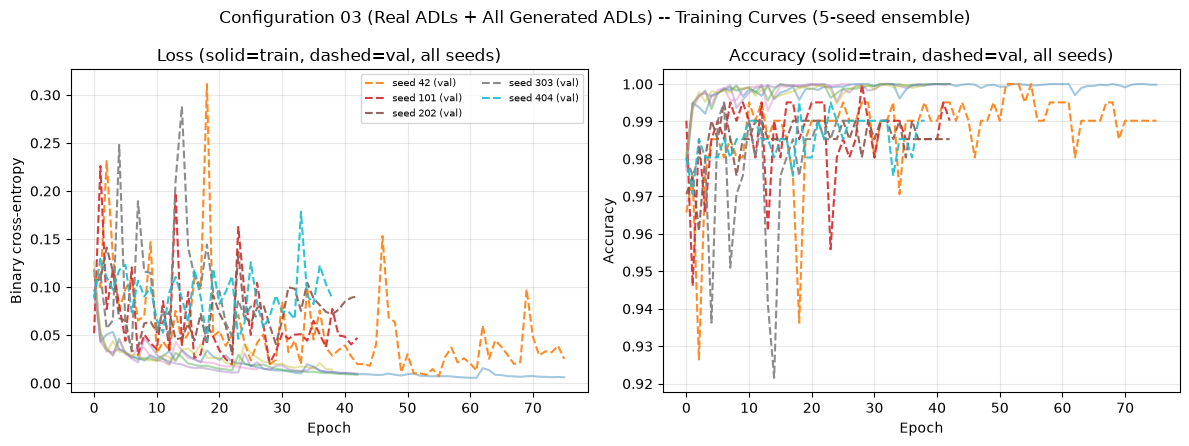

[Saved] Training curves -> Results\03-Real_ADLs+All_Generated_ADLs\config03_training_curves.png


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for s, h in zip(SEEDS, histories_all):
    axes[0].plot(h["loss"], alpha=0.4)
    axes[0].plot(h["val_loss"], alpha=0.9, linestyle="--", label=f"seed {s} (val)")
    axes[1].plot(h["accuracy"], alpha=0.4)
    axes[1].plot(h["val_accuracy"], alpha=0.9, linestyle="--")

axes[0].set_title("Loss (solid=train, dashed=val, all seeds)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].set_title("Accuracy (solid=train, dashed=val, all seeds)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

fig.suptitle("Configuration 03 (Real ADLs + All Generated ADLs) -- Training Curves (5-seed ensemble)")
fig.tight_layout()

curves_path = os.path.join(OUTPUT_DIR, "config03_training_curves.png")
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] Training curves -> {curves_path}")


## 9. Final Evaluation on the REAL Test Set

Evaluated once, on the best checkpoint, on the REAL-only, held-out-subject test set —
directly comparable to the Configuration 01 and Configuration 02 test evaluations.
`FALL = positive class`, `NON_FALL = negative class`.

In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)

# y_test_prob was already computed by the 5-seed ensembling cell above (averaged probabilities)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_test_pred, pos_label=1, zero_division=0)   # Sensitivity
f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])  # rows/cols: [NON_FALL, FALL]
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
balanced_acc = (recall + specificity) / 2

print("=" * 60)
print("FINAL TEST SET EVALUATION -- Configuration 03 (Real ADLs + All Generated ADLs)")
print("Test set is REAL-only, held-out subjects. Positive class = FALL.")
print("=" * 60)
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")

print("\nConfusion matrix (rows=true, cols=pred, order=[NON_FALL, FALL]):")
print(cm)

print("\nClassification report:")
report_str = classification_report(
    y_test, y_test_pred, target_names=["NON_FALL", "FALL"], zero_division=0
)
print(report_str)


FINAL TEST SET EVALUATION -- Configuration 03 (Real ADLs + All Generated ADLs)
Test set is REAL-only, held-out subjects. Positive class = FALL.
Accuracy           : 0.9798
Precision          : 0.8261
Recall (Sensitivity): 1.0000
F1-score           : 0.9048
Specificity        : 0.9777
Balanced Accuracy  : 0.9888
ROC-AUC            : 0.9906
PR-AUC             : 0.8918

Confusion matrix (rows=true, cols=pred, order=[NON_FALL, FALL]):
[[175   4]
 [  0  19]]

Classification report:
              precision    recall  f1-score   support

    NON_FALL       1.00      0.98      0.99       179
        FALL       0.83      1.00      0.90        19

    accuracy                           0.98       198
   macro avg       0.91      0.99      0.95       198
weighted avg       0.98      0.98      0.98       198



In [28]:
# --- Bootstrap CI on TEST metrics (quantifies how much n=19 falls can wobble) -
rng = np.random.default_rng(SEED)
n_boot = 2000
idx = np.arange(len(y_test))
boot_f1, boot_rec, boot_prec = [], [], []

for _ in range(n_boot):
    sample = rng.choice(idx, size=len(idx), replace=True)
    if y_test[sample].sum() == 0:       # skip resamples with no FALL cases
        continue
    boot_f1.append(f1_score(y_test[sample], y_test_pred[sample], zero_division=0))
    boot_rec.append(recall_score(y_test[sample], y_test_pred[sample], zero_division=0))
    boot_prec.append(precision_score(y_test[sample], y_test_pred[sample], zero_division=0))

def ci(vals):
    return np.percentile(vals, [2.5, 97.5])

print(f"F1 95% CI        : [{ci(boot_f1)[0]:.3f}, {ci(boot_f1)[1]:.3f}]")
print(f"Recall 95% CI    : [{ci(boot_rec)[0]:.3f}, {ci(boot_rec)[1]:.3f}]")
print(f"Precision 95% CI : [{ci(boot_prec)[0]:.3f}, {ci(boot_prec)[1]:.3f}]")

F1 95% CI        : [0.788, 0.980]
Recall 95% CI    : [1.000, 1.000]
Precision 95% CI : [0.650, 0.960]


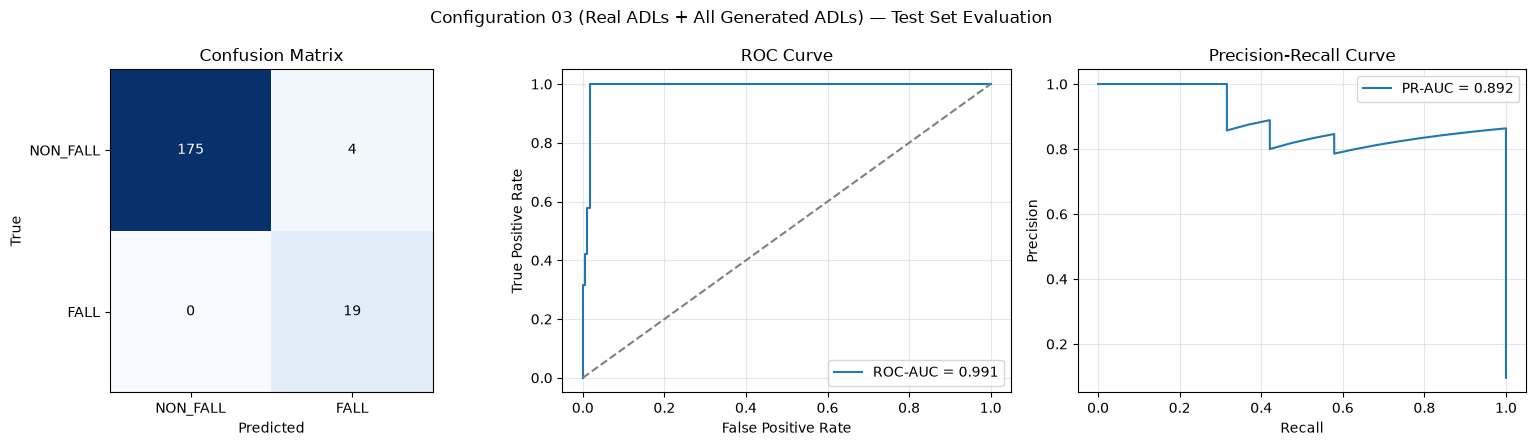

[Saved] Evaluation plots -> Results\03-Real_ADLs+All_Generated_ADLs\config03_evaluation_plots.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["NON_FALL", "FALL"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["NON_FALL", "FALL"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_prob)
axes[2].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.3f}")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Configuration 03 (Real ADLs + All Generated ADLs) — Test Set Evaluation")
fig.tight_layout()

eval_plot_path = os.path.join(OUTPUT_DIR, "config03_evaluation_plots.png")
fig.savefig(eval_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] Evaluation plots -> {eval_plot_path}")


## 10. Save Model, Metrics, and Reproducibility Artifacts

In [30]:
cm_path = os.path.join(OUTPUT_DIR, "config03_confusion_matrix.csv")
pd.DataFrame(cm, index=["true_NON_FALL", "true_FALL"],
             columns=["pred_NON_FALL", "pred_FALL"]).to_csv(cm_path)
print(f"[Saved] Confusion matrix -> {cm_path}")

report_path = os.path.join(OUTPUT_DIR, "config03_classification_report.txt")
with open(report_path, "w") as f:
    f.write(report_str)
print(f"[Saved] Classification report -> {report_path}")

cw_path = os.path.join(OUTPUT_DIR, "config03_class_weights.json")
with open(cw_path, "w") as f:
    json.dump(class_weights, f, indent=2)
print(f"[Saved] Class weights -> {cw_path}")

results_row = {
    "config": CONFIG_NAME,
    "n_train": len(y_train),
    "n_train_real": int(real_train_mask.sum()),
    "n_train_generated": int(gen_source_in_train.sum()),
    "n_excluded_generated": int(excluded_mask.sum()),
    "n_val": len(y_val),
    "n_test": len(y_test),
    "accuracy": acc,
    "precision": precision,
    "recall_sensitivity": recall,
    "f1_score": f1,
    "specificity": specificity,
    "balanced_accuracy": balanced_acc,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "seeds": str(SEEDS),
}
results_csv_path = os.path.join(OUTPUT_DIR, "config03_results.csv")
pd.DataFrame([results_row]).to_csv(results_csv_path, index=False)
print(f"[Saved] Compact results -> {results_csv_path}")

print("\n" + "=" * 60)
print("All Configuration 03 artifacts saved to:", OUTPUT_DIR)
print("=" * 60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)

print("\nAll three configurations' test sets are REAL-only, subject-disjoint, and use "
      "the same 1D CNN and training procedure — combine config01_results.csv, "
      "config02_results.csv, and config03_results.csv for the final comparison table.")


[Saved] Confusion matrix -> Results\03-Real_ADLs+All_Generated_ADLs\config03_confusion_matrix.csv
[Saved] Classification report -> Results\03-Real_ADLs+All_Generated_ADLs\config03_classification_report.txt
[Saved] Class weights -> Results\03-Real_ADLs+All_Generated_ADLs\config03_class_weights.json
[Saved] Compact results -> Results\03-Real_ADLs+All_Generated_ADLs\config03_results.csv

All Configuration 03 artifacts saved to: Results\03-Real_ADLs+All_Generated_ADLs
 - config03_class_weights.json
 - config03_classification_report.txt
 - config03_confusion_matrix.csv
 - config03_evaluation_plots.png
 - config03_history_per_seed.json
 - config03_normalization.npz
 - config03_results.csv
 - config03_split.json
 - config03_training_curves.png

All three configurations' test sets are REAL-only, subject-disjoint, and use the same 1D CNN and training procedure — combine config01_results.csv, config02_results.csv, and config03_results.csv for the final comparison table.
